# 75% or 100% overlap — does the threshold change the answer?

A predicted item counts as a match when enough of **its own words** appear in the
annotation item. "Enough" is the threshold. At 75% an item may carry a few words
the annotation does not have; at 100% every word must be there.

The question for this notebook: does tightening it change what we conclude?


In [1]:
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

from dmpbridge.core import paths as P
from dmpbridge.evaluation.evaluate import (
    containment, extract_gold, load_method, micro_prf1,
    resolve_old_gt_path, tokenize,
)
from dmpbridge.evaluation.annotation_rules import load_method_new

MODELS = ['llama3.1:8b', 'gemma4:e4b', 'llama3.3:70b']
EXTRACTOR = 'pdfplumber'
SAMPLES = range(1, 11)

# Both thresholds are passed explicitly below, so this notebook does not
# depend on whatever CONTAINMENT_THRESHOLD happens to be set to.
THRESHOLDS = [0.75, 1.0]


## Step 1 — What the threshold actually does

One real item, scored both ways.


In [2]:
gold = extract_gold(resolve_old_gt_path(2))
pred = [t for t, _ in extract_gold(P.structured_path(
    P.make_tag('llama3.3:70b', EXTRACTOR), 2))
    if t.startswith('Roles & Responsibilities')][0]

best, best_gold = max(((containment(tokenize(pred), tokenize(g)), g)
                       for g, _ in gold), key=lambda x: x[0])
extra = sorted(tokenize(pred) - tokenize(best_gold))

print(f'the model produced : {pred[:78]}')
print(f'the annotation has : {best_gold[:78]}')
print()
print(f'words in the prediction that the annotation does not have: {extra}')
print(f'overlap: {best:.0%}')
print()
print(f'  at a 75% threshold  -> {best:.0%} >= 75%   counted as a match')
print(f'  at a 100% threshold -> {best:.0%} <  100%  not counted')


the model produced : Roles & Responsibilities. For the proposed research, Director Samuel Stupp wit
the annotation has : For the proposed research, Director Samuel Stupp with help from the Executive 

words in the prediction that the annotation does not have: ['responsibilities', 'roles']
overlap: 83%

  at a 75% threshold  -> 83% >= 75%   counted as a match
  at a 100% threshold -> 83% <  100%  not counted


Two extra words — the heading `Roles & Responsibilities.` stuck to the front of the
answer — are the whole difference between a match and a miss.


## Step 2 — Every model, both paths, both thresholds

Path A scores stage 3 against the original annotation. Path B scores stage 4, after
the rules are applied, against the revised annotation. They use different reference
versions, so read them side by side rather than as two opinions on one number.


In [3]:
rows = []
for model in MODELS:
    tag = P.make_tag(model, EXTRACTOR)
    for thr in THRESHOLDS:
        a = micro_prf1(load_method(tag, threshold=thr)[1])
        b = micro_prf1(load_method_new(tag, threshold=thr)[1])
        rows.append({'model': model, 'threshold': f'{thr:.0%}',
                     'Path A f1': a['f1'], 'Path A tp': a['tp'],
                     'Path B f1': b['f1'], 'Path B tp': b['tp']})

scores = pd.DataFrame(rows).set_index(['model', 'threshold'])
display(scores.style.format({'Path A f1': '{:.3f}', 'Path B f1': '{:.3f}'}))


In [4]:
change = pd.DataFrame([
    {'model': m,
     'Path A f1': scores.loc[(m, '100%'), 'Path A f1'] - scores.loc[(m, '75%'), 'Path A f1'],
     'Path A tp': scores.loc[(m, '100%'), 'Path A tp'] - scores.loc[(m, '75%'), 'Path A tp'],
     'Path B f1': scores.loc[(m, '100%'), 'Path B f1'] - scores.loc[(m, '75%'), 'Path B f1'],
     'Path B tp': scores.loc[(m, '100%'), 'Path B tp'] - scores.loc[(m, '75%'), 'Path B tp']}
    for m in MODELS]).set_index('model')

print('change when tightening 75% -> 100%\n')
display(change.style.format({'Path A f1': '{:+.3f}', 'Path B f1': '{:+.3f}',
                            'Path A tp': '{:+d}', 'Path B tp': '{:+d}'}))


change when tightening 75% -> 100%



,Path A f1,Path A tp,Path B f1,Path B tp
model,,,,
llama3.1:8b,-0.011,-3,-0.010,-3
gemma4:e4b,-0.033,-5,-0.027,-5
llama3.3:70b,-0.020,-3,-0.016,-3


**Every score falls, and the order of the models never changes.** The largest drop is
0.033 f1 — gemma4:e4b losing 5 matched items out of 103. Measured run-to-run noise on
this pipeline is ±0.002, so these drops are real, just small.


saved for slides -> Report-doc\threshold_75_vs_100.png


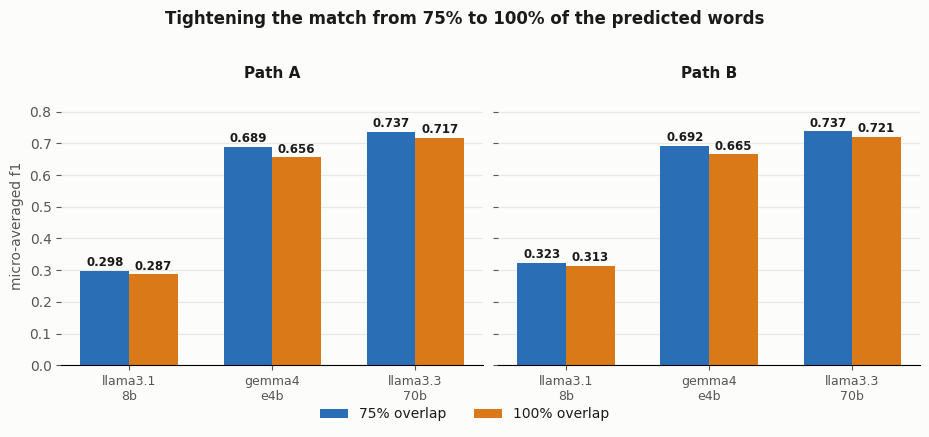

In [5]:
# Colours checked for colour-blind separation rather than chosen by eye.
C75, C100 = '#2a6fb5', '#d97917'
INK, MUTED, SURFACE, GRID = '#1a1a19', '#575653', '#fcfcfb', '#e8e8e4'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': MUTED,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'legend.frameon': False,
})

fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.0), sharey=True)
x, w = np.arange(len(MODELS)), 0.34

for ax, path in zip(axes, ('Path A', 'Path B')):
    v75 = [scores.loc[(m, '75%'), f'{path} f1'] for m in MODELS]
    v100 = [scores.loc[(m, '100%'), f'{path} f1'] for m in MODELS]
    b1 = ax.bar(x - w / 2, v75, w, color=C75, label='75% overlap')
    b2 = ax.bar(x + w / 2, v100, w, color=C100, label='100% overlap')
    for bars, vals in ((b1, v75), (b2, v100)):
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.015, f'{v:.3f}',
                    ha='center', fontsize=8.5, fontweight='bold', color=INK)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(':', '\n') for m in MODELS], fontsize=9)
    ax.set_title(path)
    ax.grid(axis='y', color=GRID, linewidth=0.9)
    ax.set_axisbelow(True)
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)

axes[0].set_ylabel('micro-averaged f1')
axes[0].set_ylim(0, 0.88)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.04))
fig.suptitle('Tightening the match from 75% to 100% of the predicted words',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()

out = Path('Report-doc/threshold_75_vs_100.png')
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=300, bbox_inches='tight', facecolor=SURFACE)
print(f'saved for slides -> {out}')
plt.show()


## Step 3 — Which items are lost, and why

Every predicted item whose overlap lands between 75% and 100%: matched under the
loose rule, dropped under the strict one. The `extra words` column is exactly what
costs it the match.


In [6]:
def lost_items(model):
    """Items that match at 75% but not at 100%, with the words that cost them."""
    tag = P.make_tag(model, EXTRACTOR)
    found = []
    for n in SAMPLES:
        sp = P.structured_path(tag, n)
        if not sp.exists():
            continue
        gold = extract_gold(resolve_old_gt_path(n))
        for ptext, plabel in extract_gold(sp):
            pt = tokenize(ptext)
            if not pt:
                continue
            best, gtext = max(((containment(pt, tokenize(g)), g) for g, _ in gold),
                              key=lambda x: x[0], default=(0.0, ''))
            if 0.75 <= best < 1.0:
                found.append({'sample': n, 'overlap': best,
                              'label': plabel,
                              'extra words': ', '.join(sorted(pt - tokenize(gtext))),
                              'predicted text': ptext[:58]})
    return pd.DataFrame(found)


for model in MODELS:
    lost = lost_items(model)
    print(f'{model}: {len(lost)} items sit between the two thresholds')
    if len(lost):
        display(lost.sort_values('overlap', ascending=False)
                .style.format({'overlap': '{:.0%}'}).hide(axis='index'))
    print()


llama3.1:8b: 9 items sit between the two thresholds


sample,overlap,label,extra words,predicted text
10,99%,answer.text,"andmanagement, cdlalso",We will ensure that the data obtained and this study will
1,98%,answer.text,sub,This secondary data analysis project will analyze deidenti
2,98%,answer.text,"develop, generalize, standards",develop or generalize standards.) Data are output from the
10,97%,answer.text,subjectafter,publication/dissemination or protection of intellectual pr
2,97%,question.text,protect,"Data management plans must protect confidentiality, person"
6,94%,section.title,types,1. Types of data. The bulk of the data generated in this p
2,91%,answer.text,"accessed, accordance, article, digital, doe, how, indicate, management, policy, principles, should, these",accordance with the Principles published in the DOE Policy
2,83%,section.title,"responsibilities, roles","Roles & Responsibilities. For the proposed research, Direc"
6,75%,section.title,"3, access, policies, sharing",3. Policies for access and sharing. Interested parties wil



gemma4:e4b: 9 items sit between the two thresholds


sample,overlap,label,extra words,predicted text
10,99%,answer.text,subjectafter,We will make the proposed nano-vesicles (NETs) available t
10,99%,answer.text,"andmanagement, cdlalso",We will ensure that the data obtained and this study will
1,98%,answer.text,sub,This secondary data analysis project will analyze deidenti
2,98%,section.description,protect,"Data management plans must protect confidentiality, person"
6,97%,answer.text,1,"code that generated it. Additionally, further backups of t"
6,94%,section.title,types,1. Types of data. The bulk of the data generated in this p
2,84%,answer.text,"conditions, doe, is, no, orders, policies, proprietary, requirement, share, there","conditions, and DOE orders and policies. There is no requi"
2,83%,section.title,"responsibilities, roles","Roles & Responsibilities. For the proposed research, Direc"
6,75%,section.title,"3, access, policies, sharing",3. Policies for access and sharing. Interested parties wil



llama3.3:70b: 7 items sit between the two thresholds


sample,overlap,label,extra words,predicted text
10,99%,answer.text,subjectafter,We will make the proposed nano-vesicles (NETs) available t
10,99%,answer.text,"andmanagement, cdlalso",We will ensure that the data obtained and this study will
2,98%,question.text,protect,"Data management plans must protect confidentiality, person"
1,98%,answer.text,sub,This secondary data analysis project will analyze deidenti
6,94%,section.title,types,1. Types of data. The bulk of the data generated in this p
2,83%,question.text,"responsibilities, roles","Roles & Responsibilities. For the proposed research, Direc"
6,75%,section.title,"3, access, policies, sharing",3. Policies for access and sharing. Interested parties wil


## Step 4 — Sorting those items into causes

Splitting them by how much text is at stake separates two different problems.


In [7]:
buckets = []
for model in MODELS:
    lost = lost_items(model)
    if not len(lost):
        continue
    buckets.append({
        'model': model,
        'one or two damaged words (95-99%)': int((lost['overlap'] >= 0.95).sum()),
        'a heading fused on (75-95%)': int((lost['overlap'] < 0.95).sum()),
    })
display(pd.DataFrame(buckets).set_index('model'))


,one or two damaged words (95-99%),a heading fused on (75-95%)
model,,
llama3.1:8b,5,4
gemma4:e4b,5,4
llama3.3:70b,4,3


**The 95–99% group is not a labeling mistake.** The predicted text is all but
identical to the annotation and fails on one or two words that the PDF text layer
damaged — a word split across a line break (`sub`), or two words run together with
the space missing (`andmanagement`, `cdlalso`, `subjectafter`).

**One of them is an error in the annotation, not in the model.** Sample 2, 98%
overlap:

```
model : Data management plans must protect confidentiality, personal privacy, ...
gold  : Data management plans must confidentiality, personal privacy, ...
```

The word *protect* is in the PDF; the annotation dropped it. At 100% the model is
penalised for being right.

**The 75–95% group is the real error** — the fused headings in samples 2 and 6, where
an underlined or numbered heading arrives glued to the front of its answer. That is
the extractor's doing, and it is counted against the model at either threshold.


## Conclusion

| question | answer |
|---|---|
| Do the scores change? | Yes, every one falls — by 0.010 to 0.033 f1 |
| Is that above noise? | Yes, the noise floor is ±0.002 |
| Does the ranking change? | No. llama3.3:70b > gemma4:e4b > llama3.1:8b at both |
| Does the conclusion change? | No |

**What the 100% threshold really measures.** It asks whether the model reproduced the
annotation word for word, so it charges the model for PDF artifacts and for one
annotation typo alongside genuine mistakes. 75% is the better measure of labeling
quality; 100% is worth reporting as a strictness check that confirms the ranking
holds.

Note that `CONTAINMENT_THRESHOLD` in `dmpbridge/evaluation/evaluate.py` sets the
default used everywhere else. This notebook passes both values explicitly, so it
does not depend on that setting.
